# Volatility Signatures of Speculative Bubbles: Main Results

This notebook walks through the core results of the project using only the
**derived data included in this repository** (no WRDS credentials needed).
It regenerates the paper's key figures inline from `data/results/`,
`data/panels/`, and `data/civ/`.

**The setup.** 27 U.S. bubble episodes (sectors that rallied 50%+ and then
drew down more than 40% within 24 months of the peak) and 42 near-bubble
controls (sectors that rallied but did not crash). 23 monthly metrics across
three channels: equity-structural (A-F), SEC filing text (G-N), and
credit-implied volatility (O-S), plus interactions (U-X). All data is
strictly pre-peak.

**Contents**
1. Episode-level AUC: can we identify which rallies will crash?
2. Permutation test: is the signal real?
3. Cox coefficients: what predicts crashes?
4. The timing null and the walk-forward caveat
5. Robustness: threshold and reporting-lag sensitivity
6. Tail risk and the two bubble regimes
7. Text-CIV validation
8. Scoring ongoing targets (AI, quantum, nuclear)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "data" / "results"
CIV = ROOT / "data" / "civ"
PANELS = ROOT / "data" / "panels"

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "figure.dpi": 110,
})

## 1. Episode-level AUC

The headline question: given a sector in the middle of a large rally, can the
model say whether it will crash (bubble) or fade quietly (near-bubble)?

We evaluate with **leverage-stratified 80/20 holdout splits**, repeated
thousands of times. Each split trains on ~55 episodes and tests on ~14; the
AUC below is at the *episode* level (one score per held-out episode, averaged
over its pre-peak months).

Two reference lines matter:
- **0.5**: chance.
- **0.780**: a naive baseline that uses the single vol-ratio metric (A) with
  no fitting at all. Any model has to beat *this*, not 0.5.

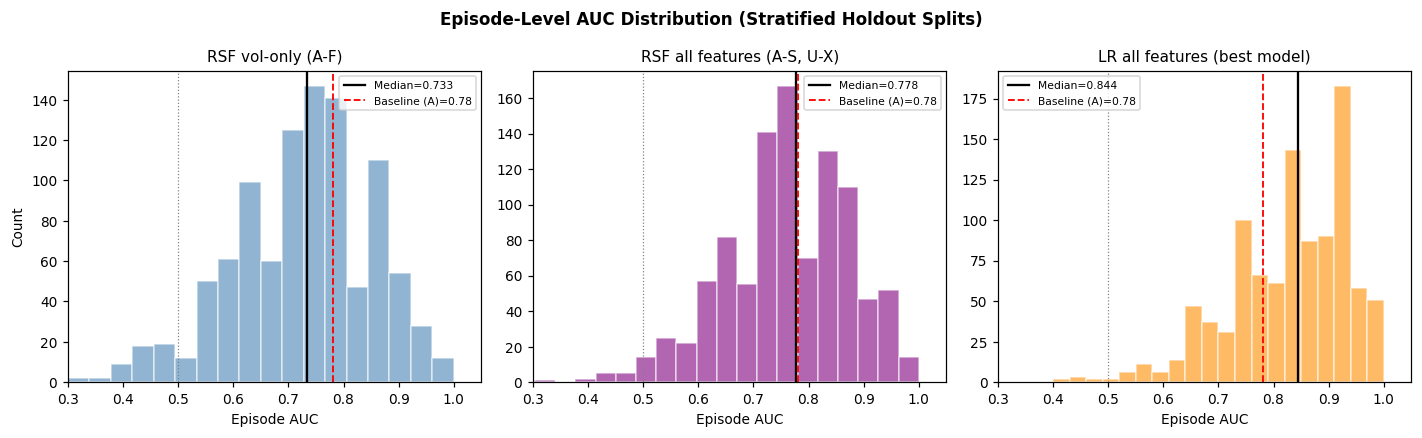

In [2]:
surv = pd.read_parquet(RESULTS / "holdout_80_20_survival.parquet")
cls = pd.read_parquet(RESULTS / "holdout_80_20_classifiers.parquet")

BASELINE = 0.780  # naive vol-ratio (metric A) episode AUC, no fitting

panels = [
    (surv[surv.feature_set == "vol_only"]["rsf_episode_auc"].dropna(),
     "steelblue", "RSF vol-only (A-F)"),
    (surv[surv.feature_set == "all"]["rsf_episode_auc"].dropna(),
     "purple", "RSF all features (A-S, U-X)"),
    (cls[cls.feature_set == "all"]["lr_auc"].dropna(),
     "darkorange", "LR all features (best model)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (vals, color, title) in zip(axes, panels):
    ax.hist(vals, bins=20, alpha=0.6, color=color, edgecolor="white")
    ax.axvline(vals.median(), color="black", lw=1.5,
               label=f"Median={vals.median():.3f}")
    ax.axvline(BASELINE, color="red", ls="--", lw=1.2,
               label=f"Baseline (A)={BASELINE}")
    ax.axvline(0.5, color="gray", ls=":", lw=0.8)
    ax.set_xlabel("Episode AUC")
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.set_xlim(0.3, 1.05)
axes[0].set_ylabel("Count")
fig.suptitle("Episode-Level AUC Distribution (Stratified Holdout Splits)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

**Reading the figure.** Logistic regression with all 23 features reaches a
median episode AUC of **0.844**, about 6pp above the un-fitted baseline.
Tree-based survival models (RSF) plateau near the baseline. Vol-only features
sit *below* the baseline: equity volatility alone does not carry the signal.

Note the width of these distributions: with only 14 test episodes per split,
a single split is nearly meaningless. This is why every claim in the project
is a *distribution* over thousands of splits, never a single number.

## 2. Permutation test: is the 0.844 real?

With 23 features and 69 episodes, a healthy dose of paranoia is warranted.
The permutation test shuffles bubble/near-bubble labels 500 times within each
of 10,000 splits (5 million null AUC values) and asks how often a
label-shuffled model matches the observed median.

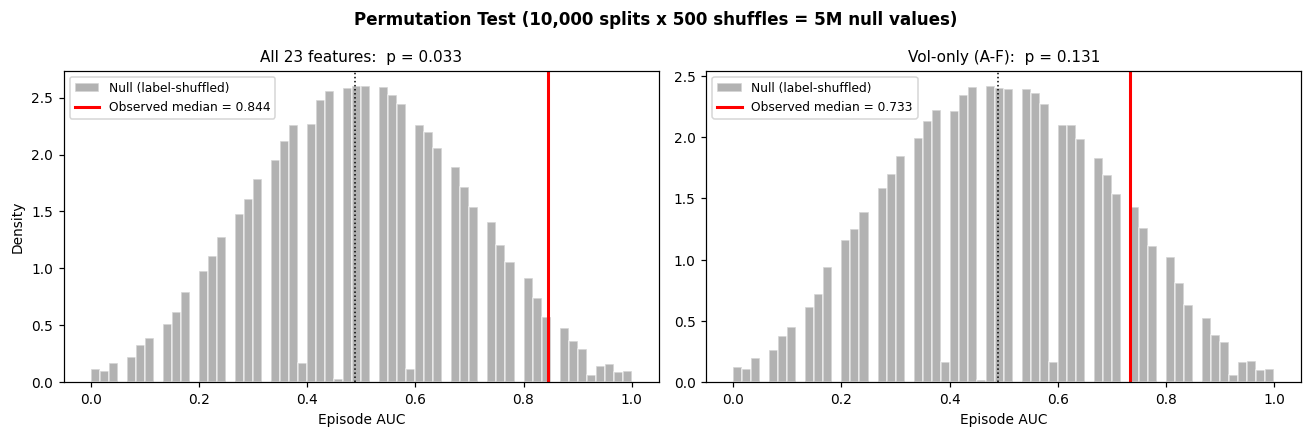

All features:  observed 0.844  null median 0.489  p = 0.0330
Vol-only:      observed 0.733  null median 0.489  p = 0.1312


In [3]:
perm_all = pd.read_csv(RESULTS / "permutation_test_all.csv").iloc[0]
perm_vol = pd.read_csv(RESULTS / "permutation_test_vol_only.csv").iloc[0]

npz_all = np.load(RESULTS / "permutation_test_all.npz")
npz_vol = np.load(RESULTS / "permutation_test_vol_only.npz")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, npz, row, title in [
    (axes[0], npz_all, perm_all, "All 23 features"),
    (axes[1], npz_vol, perm_vol, "Vol-only (A-F)"),
]:
    null = npz["null"]
    obs = row["observed_median"]
    ax.hist(null, bins=60, alpha=0.6, color="gray", edgecolor="white",
            density=True, label="Null (label-shuffled)")
    ax.axvline(obs, color="red", lw=2,
               label=f"Observed median = {obs:.3f}")
    ax.axvline(np.median(null), color="black", ls=":", lw=1)
    ax.set_xlabel("Episode AUC")
    ax.set_title(f"{title}:  p = {row['p_value']:.3f}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
fig.suptitle("Permutation Test (10,000 splits x 500 shuffles = 5M null values)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"All features:  observed {perm_all['observed_median']:.3f}  "
      f"null median {perm_all['null_median']:.3f}  p = {perm_all['p_value']:.4f}")
print(f"Vol-only:      observed {perm_vol['observed_median']:.3f}  "
      f"null median {perm_vol['null_median']:.3f}  p = {perm_vol['p_value']:.4f}")

**Reading the figure.** The full multi-channel model is significant at
**p = 0.033**; the vol-only model is **not** (p = 0.131). The SEC-text,
credit, and interaction channels carry the statistical significance;
equity volatility alone is indistinguishable from noise at the episode level.

One caveat we disclose: two feature sets were tested, so the
Bonferroni-adjusted p-value for the full model is about 0.066.

## 3. Cox coefficients: what predicts crashes?

Cox proportional-hazards coefficients (per 1 SD, medians and 95% intervals
across holdout splits, vol+SEC feature set). Red bars have intervals that
exclude zero.

The signs are the interesting part, and most contradict textbook bubble
theory.

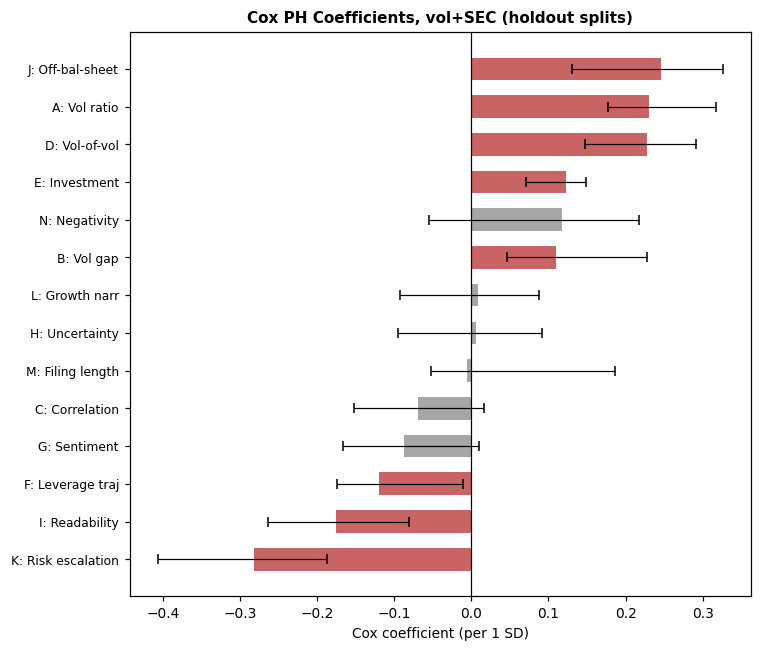

In [4]:
vs = surv[surv.feature_set == "vol_sec"].copy()
metrics = list("abcdefghijklmn")
desc = {
    "A": "A: Vol ratio", "B": "B: Vol gap", "C": "C: Correlation",
    "D": "D: Vol-of-vol", "E": "E: Investment", "F": "F: Leverage traj",
    "G": "G: Sentiment", "H": "H: Uncertainty", "I": "I: Readability",
    "J": "J: Off-bal-sheet", "K": "K: Risk escalation", "L": "L: Growth narr",
    "M": "M: Filing length", "N": "N: Negativity",
}
records = []
for m in metrics:
    col = f"cox_beta_metric_{m}"
    if col not in vs.columns:
        continue
    vals = vs[col].dropna()
    if len(vals) < 10:
        continue
    records.append({"metric": m.upper(), "median": vals.median(),
                    "lo": vals.quantile(0.025), "hi": vals.quantile(0.975)})
df = pd.DataFrame(records).sort_values("median")

fig, ax = plt.subplots(figsize=(7, 6))
y = range(len(df))
colors = ["firebrick" if (r.lo > 0 or r.hi < 0) else "gray"
          for r in df.itertuples()]
ax.barh(list(y), df["median"].values, color=colors, alpha=0.7, height=0.6)
ax.errorbar(df["median"].values, list(y),
            xerr=[df["median"].values - df["lo"].values,
                  df["hi"].values - df["median"].values],
            fmt="none", color="black", capsize=3, lw=0.8)
ax.set_yticks(list(y))
ax.set_yticklabels([desc[m] for m in df["metric"]], fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Cox coefficient (per 1 SD)")
ax.set_title("Cox PH Coefficients, vol+SEC (holdout splits)",
             fontweight="bold")
plt.tight_layout()
plt.show()

**Reading the figure.**
- **Risk-escalation language (K) is the strongest predictor, and it is
  negative**: firms that escalate their risk disclosures are *less* likely to
  crash. Transparency helps.
- **Off-balance-sheet language (J) is the strongest positive**: opacity
  predicts crashes.
- **Intra-sector correlation (C) is noise**: "herding" is not a crash signal
  here.
- **Rising leverage (F) is negative**: leverage growth marks expansion, not
  imminent danger. (Leverage *level* matters, via the interaction terms.)

## 4. The timing null and the walk-forward caveat

Two honest negatives, both disclosed prominently in the paper.

**Timing is null.** A month-level classifier appears to time crashes
(AUC ~0.685), but that signal decomposes entirely into (i) an implicit clock,
since all pre-peak windows end at a hindsight-known peak, and (ii)
cross-episode level differences. Within fixed pre-peak windows, every feature
is at chance.

**No out-of-era edge.** Under expanding walk-forward evaluation (train only
on episodes that peaked before the cutoff), the *un-fitted baseline beats the
trained model at every cutoff*. The +6pp edge over the baseline exists only
within-era (random splits).

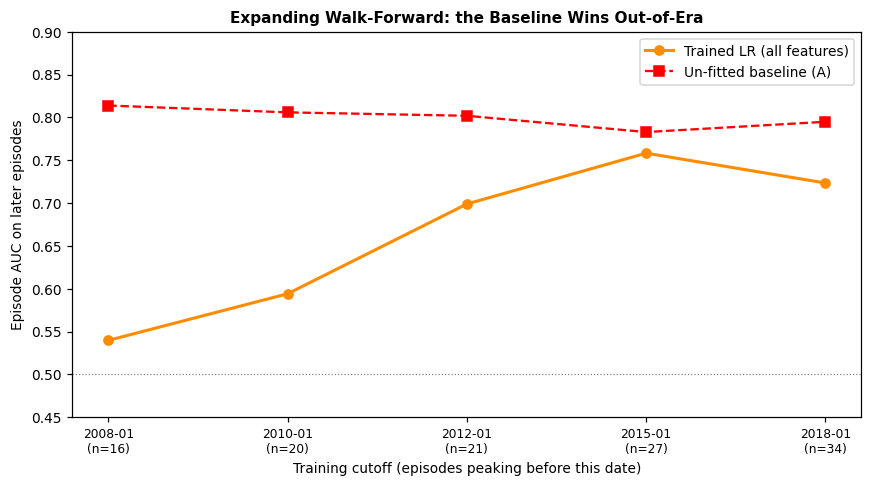

 cutoff  n_train_total  n_test_total   lr_auc
2008-01             16            53 0.539683
2010-01             20            49 0.594118
2012-01             21            48 0.698990
2015-01             27            42 0.758333
2018-01             34            35 0.723485


In [5]:
ewf = pd.read_csv(RESULTS / "robustness" / "expanding_walk_forward.csv")

# Un-fitted vol-ratio baseline AUC at each cutoff, computed in the project
# audit (deep_audit_2026_07_09) from the same test sets.
BASELINE_BY_CUTOFF = [0.814, 0.806, 0.802, 0.783, 0.795]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(ewf))
ax.plot(x, ewf["lr_auc"], "o-", color="darkorange", lw=2,
        label="Trained LR (all features)")
ax.plot(x, BASELINE_BY_CUTOFF, "s--", color="red", lw=1.5,
        label="Un-fitted baseline (A)")
ax.axhline(0.5, color="gray", ls=":", lw=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(
    [f"{c}\n(n={n})" for c, n in zip(ewf["cutoff"], ewf["n_train_total"])],
    fontsize=8)
ax.set_xlabel("Training cutoff (episodes peaking before this date)")
ax.set_ylabel("Episode AUC on later episodes")
ax.set_ylim(0.45, 0.9)
ax.legend(fontsize=9)
ax.set_title("Expanding Walk-Forward: the Baseline Wins Out-of-Era",
             fontweight="bold")
plt.tight_layout()
plt.show()

print(ewf[["cutoff", "n_train_total", "n_test_total", "lr_auc"]]
      .to_string(index=False))

**Reading the figure.** The trained model needs roughly 20+ training
episodes before it even approaches the baseline, and it never overtakes it
out-of-era. A practitioner in, say, 2010 would have been better off with the
raw vol ratio. The multi-channel signal is real (the permutation test says
so) but it is an *in-era, cross-sectional* signal, not a forward-deployable
one on this sample size.

## 5. Robustness

Two of the paper's robustness checks, reproduced from stored results:

- **Drawdown threshold.** The 40% cutoff defining "bubble" is a choice.
  Sweeping it from 30% to 50% relabels episodes; AUC stays above 0.82 for
  thresholds of 35-50%.
- **Reporting lag.** Compustat fundamentals are only public with a lag.
  Lagging all accounting inputs by 0-90 days barely moves the AUC.

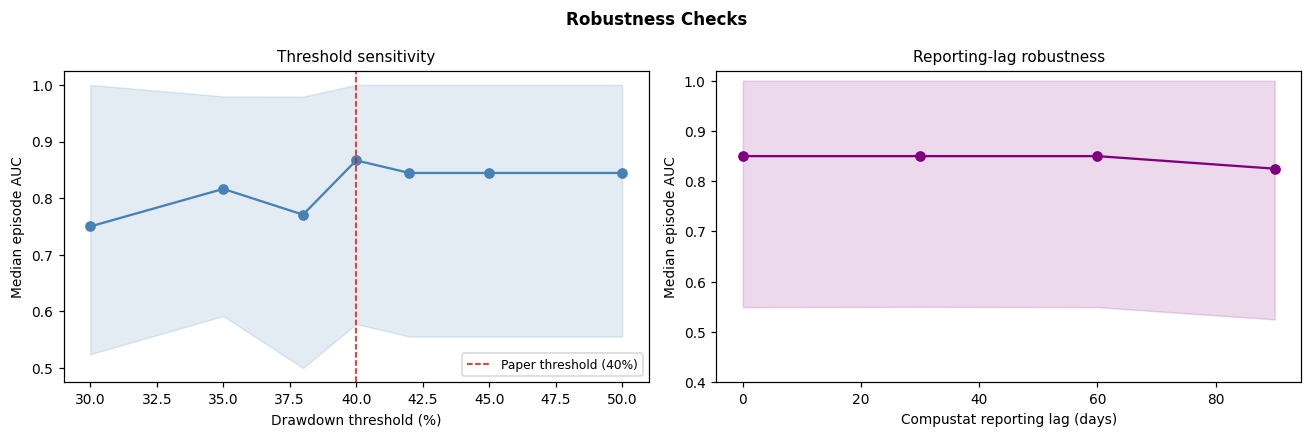

In [6]:
thresh = pd.read_csv(RESULTS / "robustness" / "threshold_sensitivity.csv")
lag = pd.read_csv(RESULTS / "robustness" / "compustat_lag.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(thresh["threshold"], thresh["median_auc"], "o-", color="steelblue")
ax.fill_between(thresh["threshold"], thresh["ci_low"], thresh["ci_high"],
                alpha=0.15, color="steelblue")
ax.axvline(40, color="red", ls="--", lw=1, label="Paper threshold (40%)")
ax.set_xlabel("Drawdown threshold (%)")
ax.set_ylabel("Median episode AUC")
ax.set_title("Threshold sensitivity")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(lag["lag_days"], lag["median_auc"], "o-", color="purple")
ax.fill_between(lag["lag_days"], lag["ci_low"], lag["ci_high"],
                alpha=0.15, color="purple")
ax.set_xlabel("Compustat reporting lag (days)")
ax.set_ylabel("Median episode AUC")
ax.set_title("Reporting-lag robustness")
ax.set_ylim(0.4, 1.02)

fig.suptitle("Robustness Checks", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Tail risk and the two bubble regimes

Left: the split-level AUC distribution with CVaR markers; the 5% worst splits
still average well above chance, but a single unlucky split can look awful.

Right: leave-one-episode-out impact on AUC. This is the clearest evidence for
the **two-regime structure**:

- Removing *leverage-bubble* episodes (banks, homebuilders, shale) hurts the
  model; it needs them to learn.
- Removing *mania* episodes (crypto, SPACs, meme stocks) *helps*: they are
  out-of-distribution for a capital-structure framework.

The model is honestly a **leveraged-fragility detector**, not a general
bubble detector.

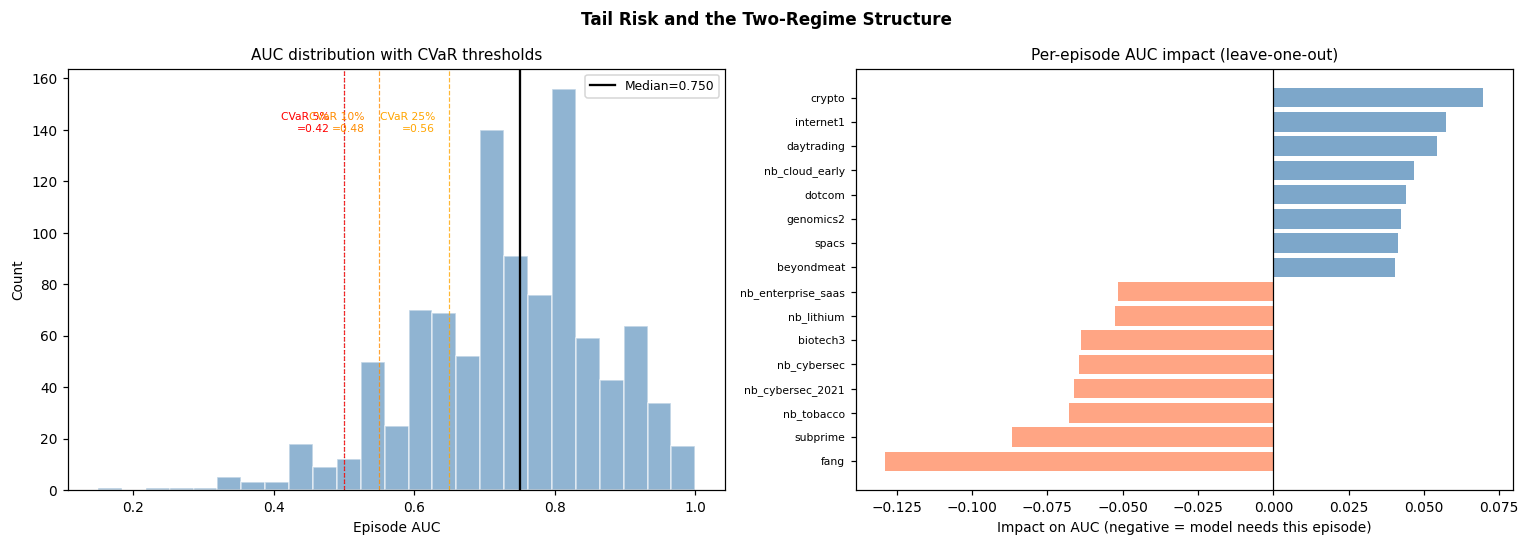

In [7]:
cvar_df = pd.read_parquet(RESULTS / "cvar_splits.parquet")
impact = pd.read_parquet(RESULTS / "episode_impact.parquet")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
vals = cvar_df["rsf_episode_auc"].dropna().sort_values().values
ax.hist(vals, bins=25, alpha=0.6, color="steelblue", edgecolor="white")
ax.axvline(np.median(vals), color="black", lw=1.5,
           label=f"Median={np.median(vals):.3f}")
ax.axvline(0.5, color="gray", ls=":", lw=0.8)
n = len(vals)
for pct, cm in [(5, "red"), (10, "darkorange"), (25, "orange")]:
    k = max(1, int(n * pct / 100))
    ax.axvline(vals[k - 1], color=cm, ls="--", lw=0.8, alpha=0.8)
    ax.text(vals[k - 1] - 0.02, ax.get_ylim()[1] * 0.85,
            f"CVaR {pct}%\n={vals[:k].mean():.2f}", fontsize=7,
            color=cm, ha="right")
ax.set_xlabel("Episode AUC")
ax.set_ylabel("Count")
ax.set_title("AUC distribution with CVaR thresholds")
ax.legend(fontsize=8)

ax = axes[1]
imp = impact.sort_values("impact")
show = pd.concat([imp.head(8), imp.tail(8)]).drop_duplicates(
    subset="episode").sort_values("impact")
colors = ["coral" if v < 0 else "steelblue" for v in show["impact"]]
ax.barh(range(len(show)), show["impact"].values, color=colors, alpha=0.7)
ax.set_yticks(range(len(show)))
ax.set_yticklabels(show["episode"].values, fontsize=7)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Impact on AUC (negative = model needs this episode)")
ax.set_title("Per-episode AUC impact (leave-one-out)")

fig.suptitle("Tail Risk and the Two-Regime Structure",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Text-CIV validation

Credit-implied volatility (CIV) from bond spreads covers only 59% of
episodes; many bubble sectors are young firms without traded bonds. The
**text-CIV** construction fills the gap: a ridge regression maps SEC-filing
NLP features to log bond spreads (out-of-fold R-squared = 0.27 at the
firm-quarter level), and the predicted spread is Merton-inverted with each
sector's actual leverage.

The scatter compares the two on overlapping sector-months. Note the two
numbers measure different things: R-squared = 0.27 is *out-of-fold spread
prediction* at the firm-quarter level; r = 0.65 is *in-sample* correlation
after sector-median aggregation and after the Merton inversion injects actual
leverage (information shared with bond-CIV). The correlation therefore
overstates the predictive content of the text alone.

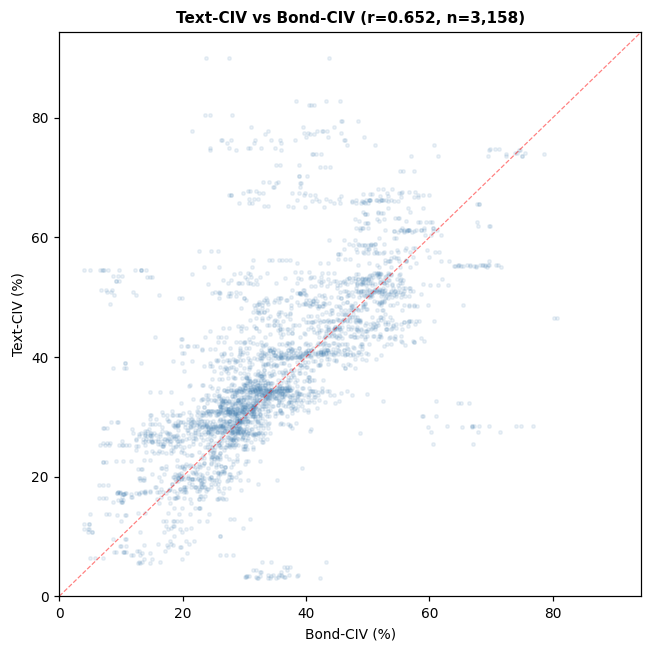

In [8]:
pairs = []
for bond_path in CIV.glob("*_bond_civ.parquet"):
    eid = bond_path.stem.replace("_bond_civ", "")
    text_path = CIV / f"{eid}_text_civ.parquet"
    if not text_path.exists():
        continue
    bond = pd.read_parquet(bond_path)
    text = pd.read_parquet(text_path)
    bond["date"] = pd.to_datetime(bond["date"])
    text["date"] = pd.to_datetime(text["date"])
    merged = bond[["date", "civ_median"]].merge(
        text[["date", "text_civ"]], on="date", how="inner").dropna()
    if not merged.empty:
        pairs.append(merged)

all_pairs = pd.concat(pairs, ignore_index=True)
corr = all_pairs["civ_median"].corr(all_pairs["text_civ"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(all_pairs.civ_median * 100, all_pairs.text_civ * 100,
           alpha=0.1, s=5, c="steelblue")
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], "r--", lw=0.8, alpha=0.5)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Bond-CIV (%)")
ax.set_ylabel("Text-CIV (%)")
ax.set_title(f"Text-CIV vs Bond-CIV (r={corr:.3f}, n={len(all_pairs):,})",
             fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Scoring ongoing targets

Finally, the model applied to three sectors that are rallying *now* and whose
outcomes are unknown: **AI**, **quantum computing**, and **nuclear/uranium**.
Scores are Cox partial hazards from the full model (higher = more
bubble-like), shown alongside the vol-only score for contrast.

These are illustrations, not forecasts: recall that the walk-forward result
says the trained model has no demonstrated out-of-era edge over the raw vol
ratio.

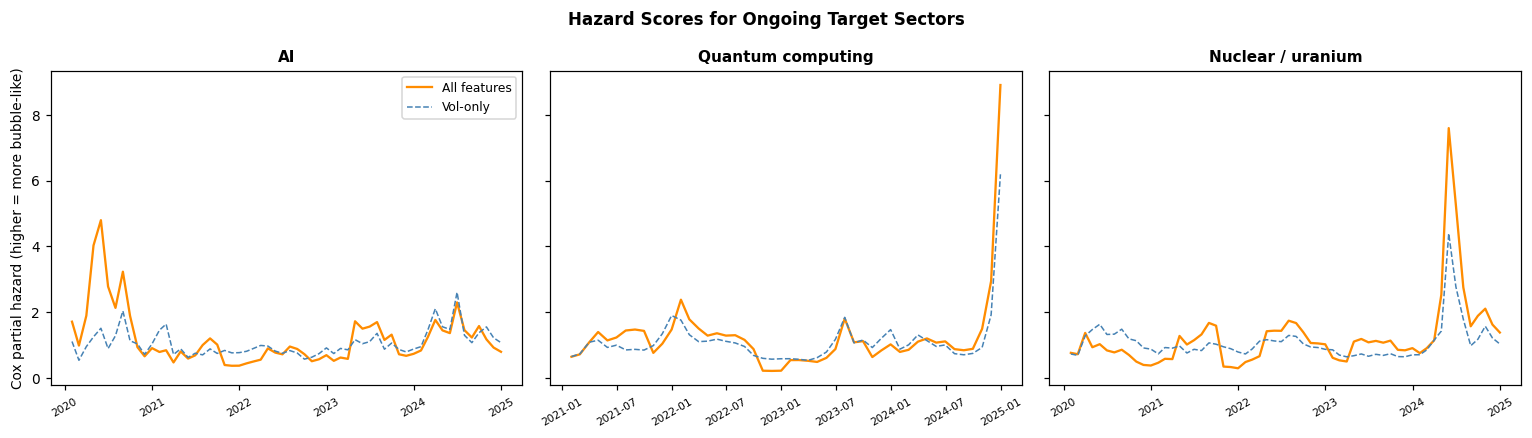

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, tgt, label in zip(axes, ["AI", "quantum", "nuclear2"],
                          ["AI", "Quantum computing", "Nuclear / uranium"]):
    full = pd.read_parquet(RESULTS / f"target_{tgt}_all.parquet")
    vol = pd.read_parquet(RESULTS / f"target_{tgt}_vol_only.parquet")
    full["date"] = pd.to_datetime(full["date"])
    vol["date"] = pd.to_datetime(vol["date"])
    ax.plot(full["date"], full["hazard"], "-", color="darkorange", lw=1.5,
            label="All features")
    ax.plot(vol["date"], vol["hazard"], "--", color="steelblue", lw=1,
            label="Vol-only")
    ax.set_title(label, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7, rotation=30)
axes[0].set_ylabel("Cox partial hazard (higher = more bubble-like)")
axes[0].legend(fontsize=8)
fig.suptitle("Hazard Scores for Ongoing Target Sectors",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

| Question | Answer |
|---|---|
| Identify which rallies crash? | Yes, modestly: LR episode AUC 0.844 vs 0.780 baseline, permutation p = 0.033 |
| Vol alone enough? | No: p = 0.131; text/credit channels carry the significance |
| Time the crash? | No: within-episode timing is at chance |
| Deployable out-of-era? | Not demonstrated: baseline wins every walk-forward cutoff |
| What kind of detector is it? | A leveraged-fragility detector, not a general bubble detector |

See `notebooks/02_case_studies.ipynb` for the multi-channel case-study
anatomy, and the repository README for the full pipeline.